# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import geopandas as gpd

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Preprocessing

In [2]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
combined_df.shape

(878189, 20)

In [3]:
# Load the bird species reference file
# UPDATE THIS PATH if your CSV file is in a different location
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/birds/bird_species_migration.csv'  # Change as needed

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


In [4]:
migration_map = dict(zip(
    bird_reference['bird_species'].str.lower(),
    bird_reference['migration_period']
))

# Map migration groups to observations
combined_df['migration_group'] = combined_df['COMMON NAME'].str.lower().map(migration_map)


In [5]:
combined_df = combined_df[combined_df['migration_group']=='F']

In [6]:
combined_df

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,NaN,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,L5281087,P,36.001314,-5.610797,2017-01-20,obsr756857,S33804365,Traveling,F
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr271019,S33940654,Traveling,F
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr427437,S33751745,Traveling,F
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr546444,S34018122,Traveling,F
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,NaN,Salinas del Carmen,L3189830,H,28.367192,-13.869656,2017-01-21,obsr777138,S33908528,Traveling,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
878184,Black Tern,Chlidonias niger,1.0,NaN,Netherlands,NL,Zuid-Holland,NL-ZH,NaN,NaN,NaN,Pretpier (Scheveningen),L16606437,H,52.117923,4.280005,2025-09-16,obsr1478235,S273768812,Stationary,F
878185,Black Tern,Chlidonias niger,1.0,NaN,Poland,PL,Kujawsko-pomorskie,PL-KP,NaN,NaN,NaN,Wojdal gravel pit lake (Zbiornik Wojdal),L21421456,H,52.854158,18.075361,2025-09-19,obsr511948,S274163270,Stationary,F
878186,Black Tern,Chlidonias niger,1.0,NaN,United Kingdom,GB,England,GB-ENG,Merseyside,GB-ENG-KWL,NaN,Fort Perch Rock,L6319595,H,53.442494,-3.040767,2025-10-05,obsr3384199,S277528628,Traveling,F
878187,Black Tern,Chlidonias niger,1.0,NaN,Ireland,IE,Connaught,IE-C,Mayo,IE-C-MO,NaN,Cross Lough,L9597842,H,54.198560,-10.077379,2025-10-09,obsr685602,S278224399,Traveling,F


In [7]:
combined_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,NaN,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,L5281087,P,36.001314,-5.610797,2017-01-20,obsr756857,S33804365,Traveling,F
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr271019,S33940654,Traveling,F
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr427437,S33751745,Traveling,F
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr546444,S34018122,Traveling,F
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,NaN,Salinas del Carmen,L3189830,H,28.367192,-13.869656,2017-01-21,obsr777138,S33908528,Traveling,F


In [8]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] != 2026]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2025-12-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [9]:
combined_df = combined_df[combined_df['year'] < 2023]
combined_df = combined_df[combined_df['COMMON NAME'] != 'Black Tern']

## 3. Basic Statistics

In [10]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 319,418
Number of countries: 46
Number of states/regions: 648
Number of counties: 1009
Number of unique species: 5
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 14952

Observations with count data: 319,418 (100.0%)
Total birds counted: 1,878,371
Average count per observation: 5.88
Median count: 1
Maximum count in single observation: 8,000
Minimum count: 1


### outlier removal for col 'howMany'

In [11]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower bound: -2.0
Upper bound: 6.0

Total outliers: 34,894 (10.92% of data)

Outlier summary:
count    34894.000000
mean        38.613573
std        167.725680
min          7.000000
25%          8.000000
50%         12.000000
75%         23.000000
max       8000.000000
Name: howMany, dtype: float64


In [12]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
7.0     4570
8.0     4249
10.0    3818
9.0     2327
12.0    1941
15.0    1640
20.0    1591
11.0    1391
14.0     972
30.0     891
13.0     843
16.0     699
25.0     696
18.0     561
50.0     560
17.0     520
40.0     478
19.0     324
22.0     301
35.0     297
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-2-50        31294
51-100        1794
101-500       1504
501-1000       163
1001-5000      135
5000+            4
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    7
  Max outlier value:    8,000
  Mean outlier value:   38.61
  Median outlier value: 12


In [13]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 1,806

Locality Type Distribution:
LOCALITY TYPE
H    1488
P     318
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    82.39%
P    17.61%
Name: proportion, dtype: object


#### dropping outliers

In [14]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 319,418
Rows after:  317,612
Rows dropped: 1,806 (0.57% of data)


## 4. Analysis by Country

In [15]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 88623


In [16]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain              129546               5             19               48             548714.0
          GB         United Kingdom               41872               5              4               98              94657.0
          PT               Portugal               39769               5             20              275             109724.0
          FR                 France               16361               5             13               96              62918.0
          DE                Germany                9649               5             16              310              26466.0
          SE                 Sweden                8199               5             21                0              24985.0
          GR                 Greece                8095               5             14               7

In [17]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

country_stats = country_stats.sort_values('Unique Observers', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers
          ES                  Spain              129546               5             19               48             548714.0              5439
          GB         United Kingdom               41872               5              4               98              94657.0              2997
          PT               Portugal               39769               5             20              275             109724.0              1833
          FR                 France               16361               5             13               96              62918.0              1566
          DE                Germany                9649               5             16              310              26466.0               951
          GR                 Greece                8095               5             14               70              53

### relative to number of observers

In [18]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

# Calculate per-observer metrics
country_stats['Obs per Observer']      = (country_stats['Total Observations'] / country_stats['Unique Observers']).round(1)
# country_stats['Species per Observer']  = (country_stats['Unique Species']      / country_stats['Unique Observers']).round(1)
# country_stats['Birds per Observer']    = (country_stats['Total Birds Counted'] / country_stats['Unique Observers']).round(1)
# country_stats['Counties per Observer'] = (country_stats['Unique Counties']     / country_stats['Unique Observers']).round(2)

country_stats = country_stats.sort_values('Obs per Observer', ascending=False)

print("\nSTATISTICS BY COUNTRY (relative to unique observers)")
print("="*150)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY (relative to unique observers)
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers  Obs per Observer
          ES                  Spain              129546               5             19               48             548714.0              5439              23.8
          MD                Moldova                 507               4             31                0               2103.0                22              23.0
          PT               Portugal               39769               5             20              275             109724.0              1833              21.7
          CZ         Czech Republic                6166               5             14                0              15123.0               330              18.7
          RS                 Serbia                1612               4             18                0               4878.0               11

## 5. Species Analysis

In [19]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
           Common Name     Scientific Name  Total Observations  Countries Found  States Found  Total Count
       Green Sandpiper     Tringa ochropus              173660               44           557     413116.0
          Little Stint     Calidris minuta               51689               43           383     286413.0
European Honey-buzzard     Pernis apivorus               44529               42           545     208528.0
      Curlew Sandpiper Calidris ferruginea               36594               39           345     184204.0
     Eurasian Whimbrel   Numenius phaeopus               11140               26           144      44364.0


## 6. Temporal Analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 28,881
  2018: 34,098
  2019: 44,130
  2020: 51,750
  2021: 69,649
  2022: 89,104

Observations by month of 2017
  January: 1,372
  February: 873
  March: 1,602
  April: 2,663
  May: 2,540
  June: 1,357
  July: 2,580
  August: 5,322
  September: 5,037
  October: 2,604
  November: 1,428
  December: 1,503
  → Peak migration month: August (5,322 observations)

Observations by month of 2018
  January: 1,785
  February: 1,397
  March: 1,766
  April: 2,913
  May: 4,008
  June: 1,836
  July: 3,522
  August: 5,733
  September: 5,593
  October: 2,285
  November: 1,528
  December: 1,732
  → Peak migration month: August (5,733 observations)

Observations by month of 2019
  January: 2,114
  February: 1,673
  March: 3,099
  April: 4,488
  May: 3,922
  June: 2,160
  July: 4,562
  August: 8,086
  September: 7,114
  October: 3,037
  November: 1,912
  December: 1,963
  → Peak migration month: August (8,086 observations)

Observations by month of 2020
  

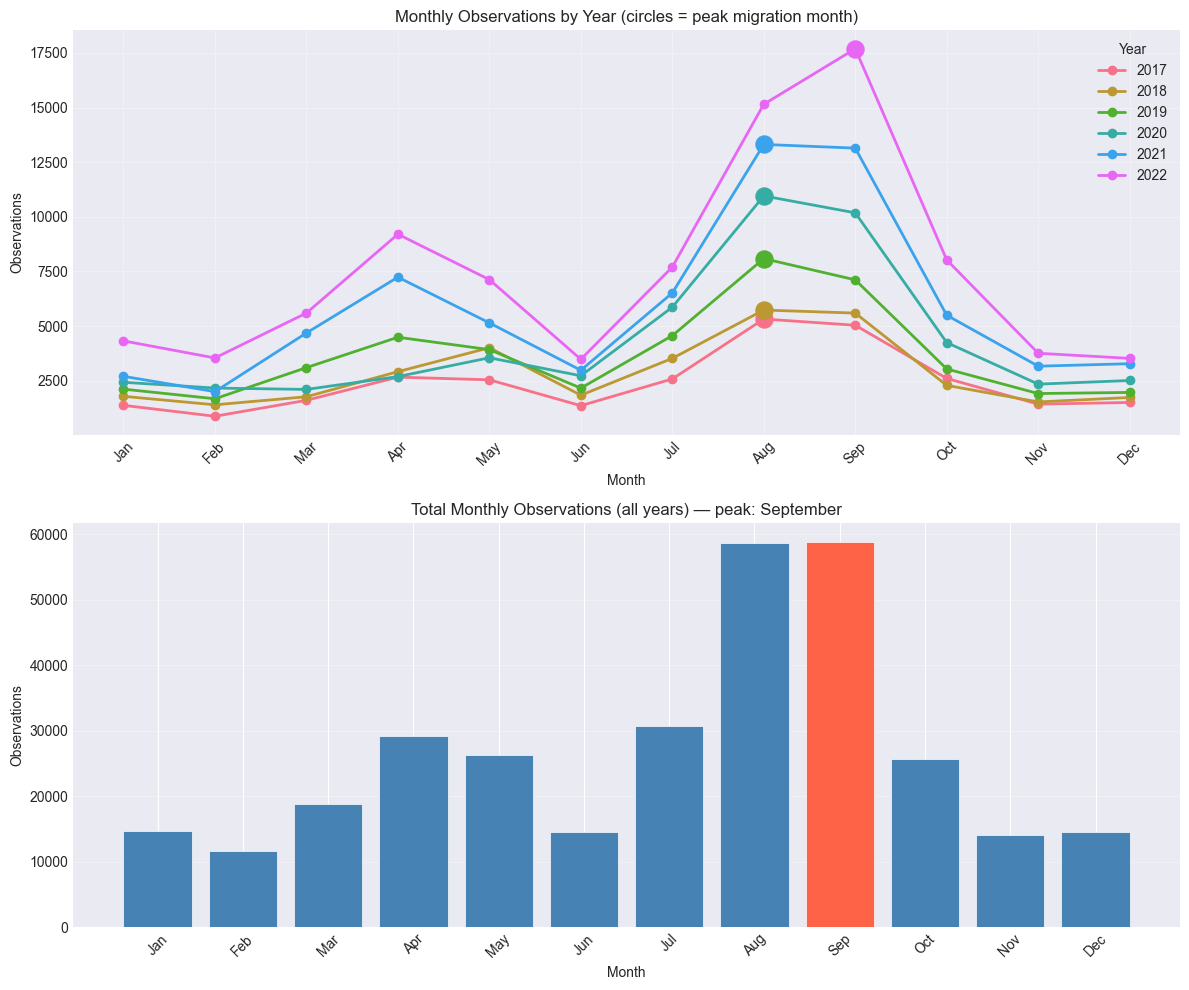

In [20]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [21]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 28,881.0 observations | 106,816.0 number of birds counted
  2018: 34,098.0 observations | 134,208.0 number of birds counted
  2019: 44,130.0 observations | 161,604.0 number of birds counted
  2020: 51,750.0 observations | 173,964.0 number of birds counted
  2021: 69,649.0 observations | 241,110.0 number of birds counted
  2022: 89,104.0 observations | 318,923.0 number of birds counted


In [22]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        # print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        # print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
    Avg bird per observer: 32.98
    Avg obs per observer: 8.92
    Avg bird per observer: 33.87
    Avg obs per observer: 8.61
    Avg bird per observer: 33.39
    Avg obs per observer: 9.12
    Avg bird per observer: 35.43
    Avg obs per observer: 10.54
    Avg bird per observer: 36.86
    Avg obs per observer: 10.65
    Avg bird per observer: 36.34
    Avg obs per observer: 10.15


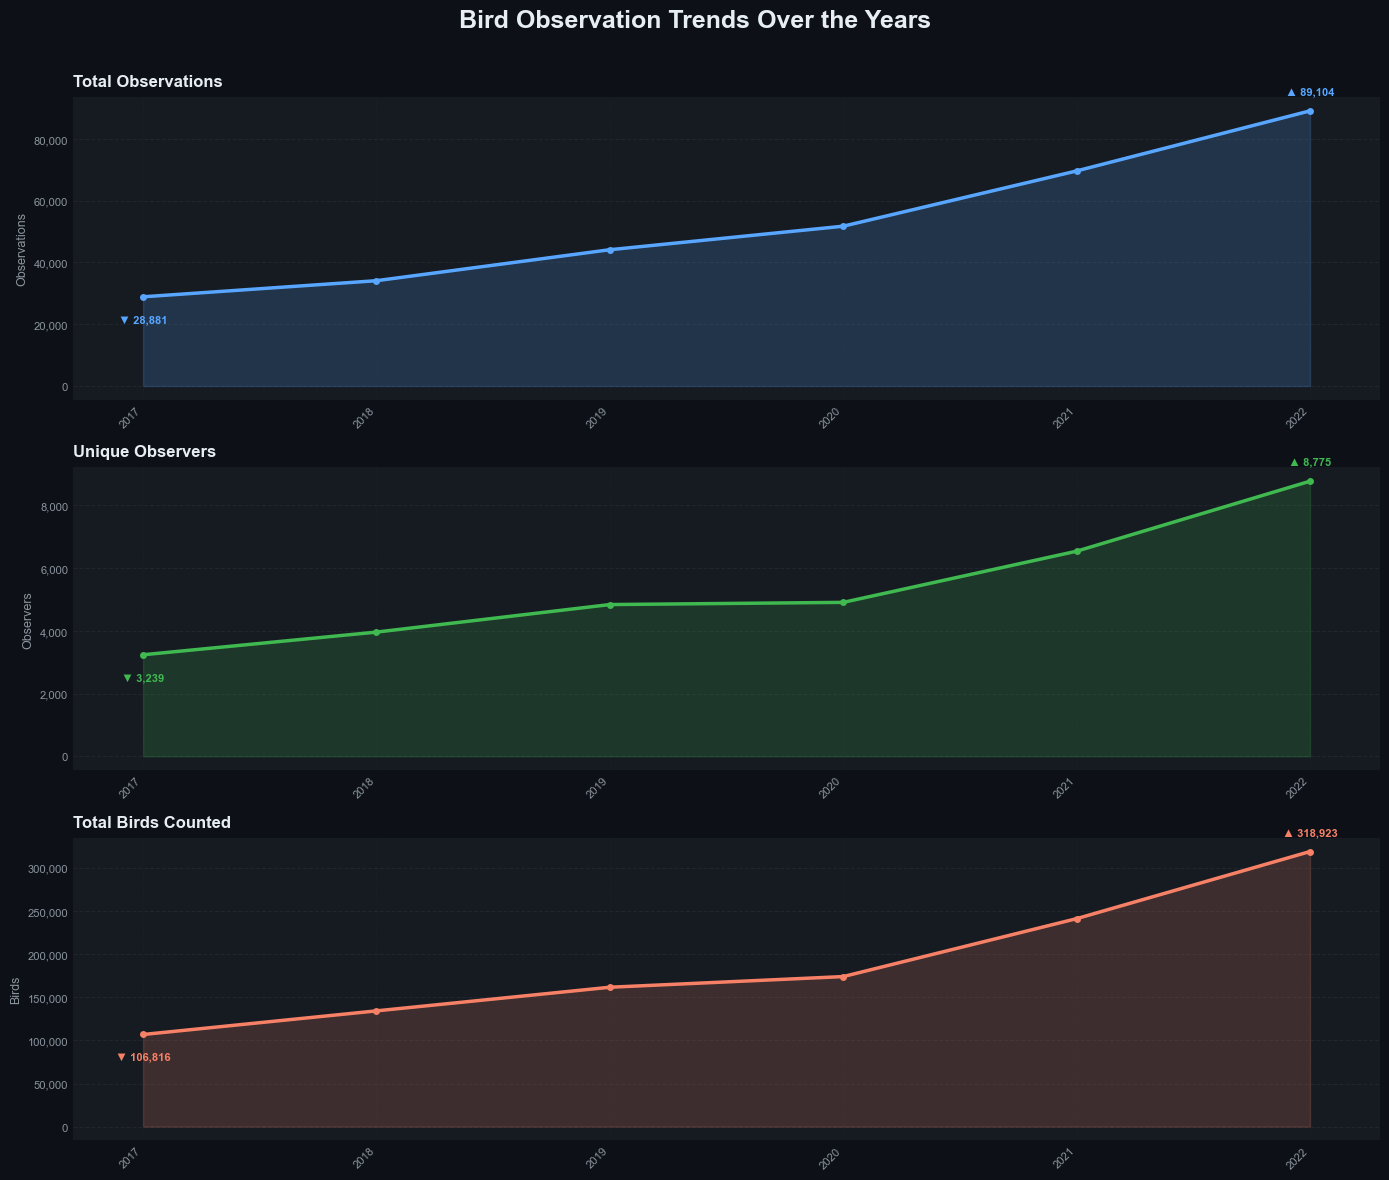

Plot saved to yearly_trends.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

### 8.3 Migration Pattern Analysis by Season

Analyzing bird sightings based on migration groups across different seasonal periods:
- **Spring Migration Period**: Mid-March to Mid-June
- **Summer Period**: July to Early August
- **Autumn Migration Period**: Late August to Early December  
- **Winter Period**: Late December to Early March

In [24]:
# Define seasonal periods
def get_season(date):
    """
    Classify observation date into seasonal periods.
    """
    if pd.isna(date):
        return 'Unknown'
    
    month = date.month
    day = date.day
    
    # Spring Migration: Mid-March (Mar 15) to Mid-June (Jun 15)
    if (month == 3 and day >= 15) or (month in [4, 5]) or (month == 6 and day <= 15):
        return 'Spring Migration (Mid-Mar to Mid-Jun)'
    
    # Summer: July and Early August (to Aug 20)
    elif month == 7 or (month == 8 and day <= 20):
        return 'Summer (Jul to Early Aug)'
    
    # Autumn Migration: Late August (Aug 21) to Early December (Dec 10)
    elif (month == 8 and day > 20) or (month in [9, 10, 11]) or (month == 12 and day <= 10):
        return 'Autumn Migration (Late Aug to Early Dec)'
    
    # Winter: Late December (Dec 11+) to Early March (Mar 14)
    else:  # (month == 12 and day > 10) or (month in [1, 2]) or (month == 3 and day < 15)
        return 'Winter (Late Dec to Early Mar)'

# Apply seasonal classification
combined_df['season'] = combined_df['obsDt'].apply(get_season)

print("Observations by season:")
season_counts = combined_df['season'].value_counts()
for season, count in season_counts.items():
    print(f"  {season}: {count:,} observations")

Observations by season:
  Autumn Migration (Late Aug to Early Dec): 128,127 observations
  Spring Migration (Mid-Mar to Mid-Jun): 73,638 observations
  Summer (Jul to Early Aug): 64,817 observations
  Winter (Late Dec to Early Mar): 51,030 observations


## 7. Distance to cities

In [25]:
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


In [26]:
df_migratory = combined_df

In [27]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_migratory[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_migratory['closest_city'] = cities['NAME'].iloc[indices].values
df_migratory['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migratory['distance_km'] = np.round(distances * 6371, 2)

df_migratory

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group,obsDt,year,month,day_of_week,day_of_year,howMany,season,closest_city,closest_city_country,distance_km
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,NaN,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,L5281087,P,36.001314,-5.610797,2017-01-20,obsr756857,S33804365,Traveling,F,2017-01-20,2017,1,4,20,2.0,Winter (Late Dec to Early Mar),Algeciras,Spain,22.80
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr271019,S33940654,Traveling,F,2017-01-16,2017,1,0,16,2.0,Winter (Late Dec to Early Mar),Huelva,Spain,6.90
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr427437,S33751745,Traveling,F,2017-01-16,2017,1,0,16,2.0,Winter (Late Dec to Early Mar),Huelva,Spain,6.90
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr546444,S34018122,Traveling,F,2017-01-16,2017,1,0,16,2.0,Winter (Late Dec to Early Mar),Huelva,Spain,6.90
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,NaN,Salinas del Carmen,L3189830,H,28.367192,-13.869656,2017-01-21,obsr777138,S33908528,Traveling,F,2017-01-21,2017,1,5,21,3.0,Winter (Late Dec to Early Mar),Rabat,Morocco,1003.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876401,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,4Ð Ð²ÑÐ»Ð¸ÑÑ ÐÑÐ²Ð´ÐµÐ½Ð½Ð¾ÐºÑÐ»ÑÑÐµÐ...,L11936119,P,48.250136,25.948428,2020-07-18,obsr1524677,S71750798,Traveling,F,2020-07-18,2020,7,5,200,1.0,Summer (Jul to Early Aug),Chernivtsi,Ukraine,6.82
876402,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,Ð²ÑÐ»Ð¸ÑÑ ÐÐ¾ÑÐºÐ¾Ð²ÑÑÐºÐ¾Ñ ÐÐ»ÑÐ¼Ð¿...,L11895530,P,48.290152,25.997833,2020-07-14,obsr1524677,S71493671,Traveling,F,2020-07-14,2020,7,1,196,1.0,Summer (Jul to Early Aug),Chernivtsi,Ukraine,8.65
876403,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, ÐÐ¾ÑÑÑÐ½Ñ Ð¨ÐµÑÑÐ²ÑÑ, Ð...",L14419836,P,48.408663,25.952795,2021-08-03,obsr1524677,S92697785,Traveling,F,2021-08-03,2021,8,1,215,1.0,Summer (Jul to Early Aug),Chernivtsi,Ukraine,12.01
876404,European Honey-buzzard,Pernis apivorus,1.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, Ð§Ð°Ð³Ð¾Ñ, Ð§ÐµÑÐ½ÑÐ²ÐµÑÑÐº...",L16080784,P,48.251779,26.012127,2021-08-12,obsr1524677,S93111782,Traveling,F,2021-08-12,2021,8,3,224,1.0,Summer (Jul to Early Aug),Chernivtsi,Ukraine,11.70


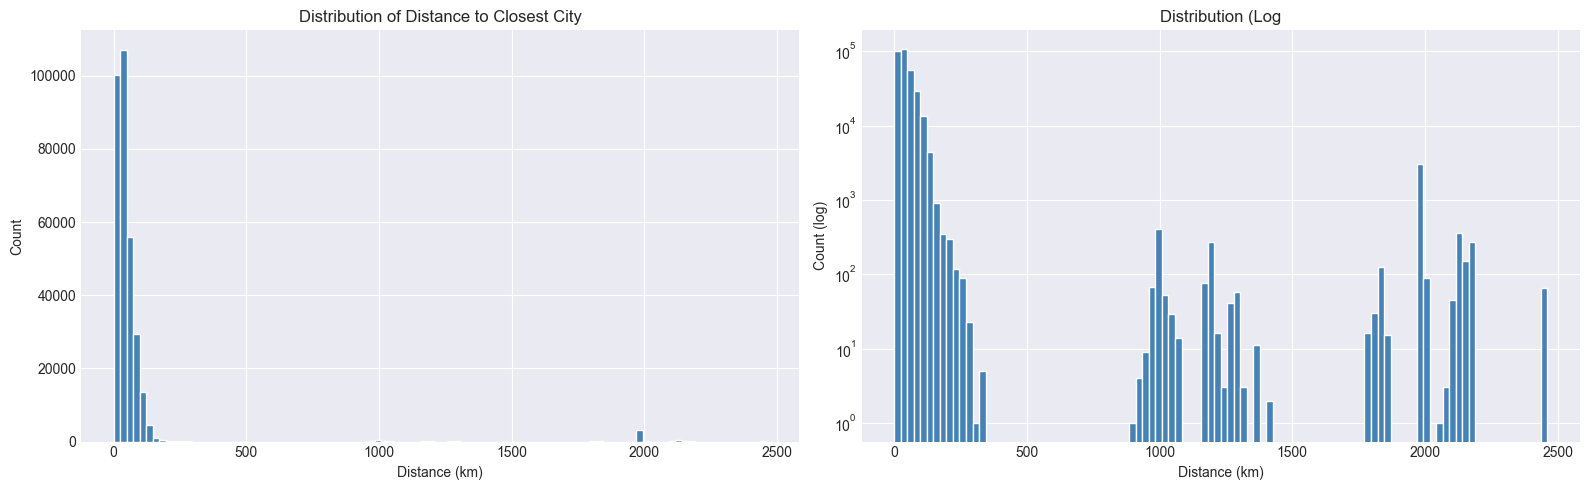

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

### Distance Aggregations

The following cells calculate the average distance to the closest city across three groupings:
1. **Per year** — how the average distance changes over time
2. **Per species** — average across all years for each species
3. **Per species per year** — the most granular breakdown

In [29]:
# --- 1. Average distance to closest city per year ---
dist_by_year = (
    df_migratory
    .dropna(subset=['distance_km', 'year'])
    .groupby('year')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('year')
)
dist_by_year['year'] = dist_by_year['year'].astype(int)

print("Average distance to closest city per year:")
print(dist_by_year.to_string(index=False))

Average distance to closest city per year:
 year  mean_distance_km  median_distance_km  n_observations
 2017         81.221291               36.94           28881
 2018         83.520147               37.79           34098
 2019         76.577716               37.25           44130
 2020         72.022322               36.11           51750
 2021         72.707952               36.72           69649
 2022         66.418481               35.85           89104


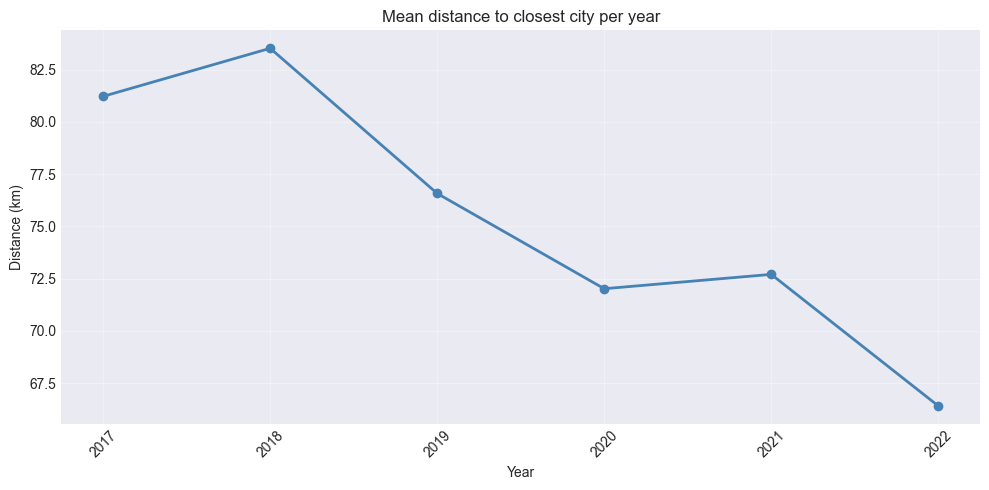

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dist_by_year['year'], dist_by_year['mean_distance_km'],
        color='steelblue', marker='o', linewidth=2, markersize=6)

ax.set_xticks(dist_by_year['year'])
ax.set_xticklabels(dist_by_year['year'], rotation=45)
ax.set_title('Mean distance to closest city per year')
ax.set_xlabel('Year')
ax.set_ylabel('Distance (km)')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

plt.tight_layout()
plt.show()

In [31]:
# --- 2. Average distance to closest city per species (across all years) ---
dist_by_species = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME'])
    .groupby('COMMON NAME')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per species (all years combined):")
print(dist_by_species.to_string(index=False))

Average distance to closest city per species (all years combined):
           COMMON NAME  mean_distance_km  median_distance_km  n_observations
     Eurasian Whimbrel        321.544883              77.345           11140
      Curlew Sandpiper        119.619915              35.260           36594
          Little Stint         97.890082              35.650           51689
       Green Sandpiper         48.148268              35.560          173660
European Honey-buzzard         42.706787              38.840           44529


In [32]:
# --- 3. Average distance to closest city per species per year ---
dist_by_species_year = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME', 'year'])
    .groupby(['COMMON NAME', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['COMMON NAME', 'year'])
)
dist_by_species_year['year'] = dist_by_species_year['year'].astype(int)

print("Average distance to closest city per species per year:")
print(dist_by_species_year.to_string(index=False))

# Optionally pivot for a cleaner species × year view
pivot_mean = dist_by_species_year.pivot(index='COMMON NAME', columns='year', values='mean_distance_km').round(2)
print("\nPivot table — mean distance (km) by species × year:")
print(pivot_mean.to_string())

Average distance to closest city per species per year:
           COMMON NAME  year  mean_distance_km  median_distance_km  n_observations
      Curlew Sandpiper  2017        157.199957              35.030            3004
      Curlew Sandpiper  2018        122.924719              34.620            3785
      Curlew Sandpiper  2019        107.419646              34.855            4854
      Curlew Sandpiper  2020        112.330849              35.260            6045
      Curlew Sandpiper  2021        150.485339              37.830            6932
      Curlew Sandpiper  2022         99.904219              35.260           11974
     Eurasian Whimbrel  2017        278.135817              85.510            1566
     Eurasian Whimbrel  2018        362.190702              85.510            1809
     Eurasian Whimbrel  2019        314.691806              79.600            2016
     Eurasian Whimbrel  2020        334.928108              83.090            1633
     Eurasian Whimbrel  2021    

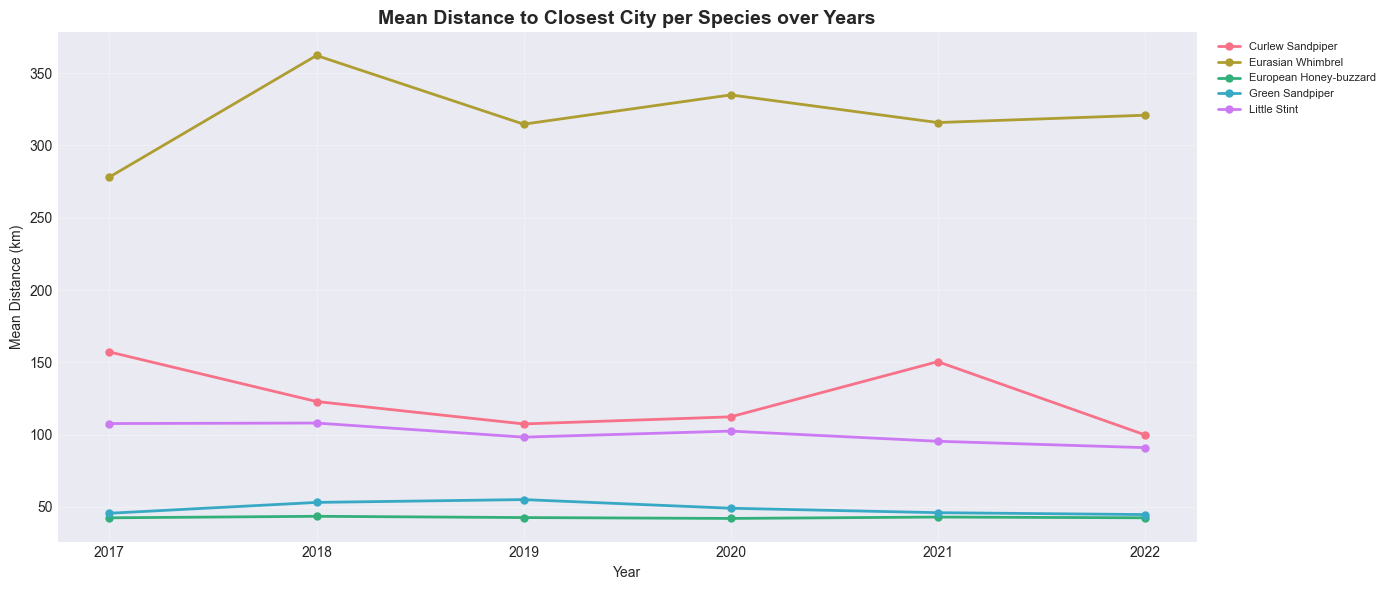

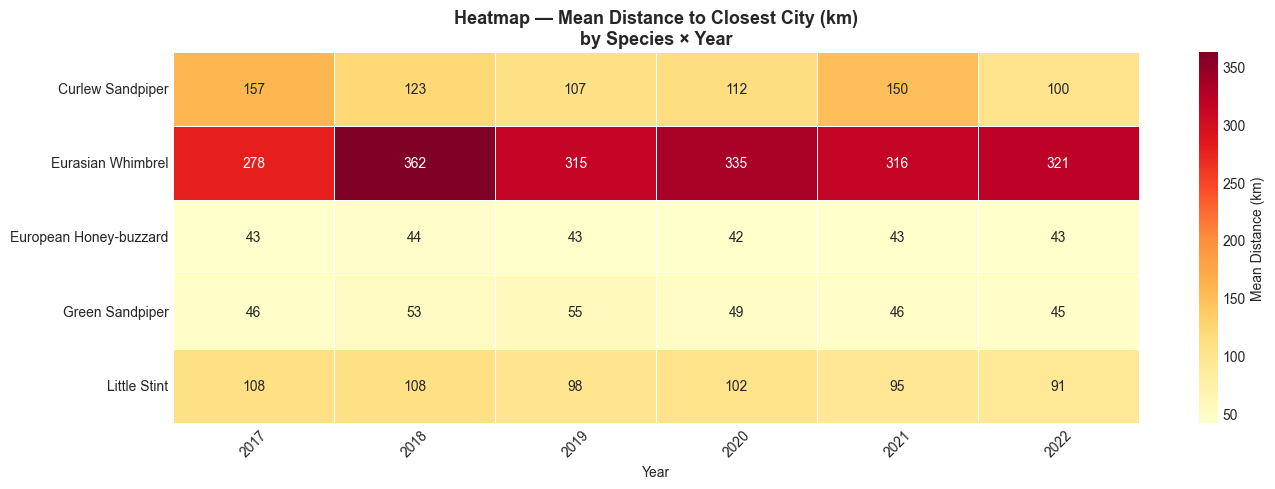

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Colour palette ──────────────────────────────────────────────────────────
species_list = dist_by_species_year['COMMON NAME'].unique()
palette = dict(zip(species_list, sns.color_palette("husl", len(species_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per species over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for species, grp in dist_by_species_year.groupby('COMMON NAME'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=species, color=palette[species])

ax.set_title('Mean Distance to Closest City per Species over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_species_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: pivot_mean (species × year)
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(5, len(species_list) * 0.45)))

sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Species × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_species_year_heatmap.png', dpi=150)
plt.show()


In [34]:
print(df_migratory['distance_km'].describe())
print(f"\nMedian:  {df_migratory['distance_km'].median():.2f} km")
print(f"Skewness: {df_migratory['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_migratory['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_migratory['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_migratory['distance_km'] <= 100).mean()*100:.1f}%")

count    317612.000000
mean         73.304347
std         237.110698
min           0.060000
25%          20.870000
50%          36.680000
75%          60.110000
max        2460.870000
Name: distance_km, dtype: float64

Median:  36.68 km
Skewness: 7.73
% within 10km:  8.6%
% within 50km:  66.2%
% within 100km: 92.3%
